In [5]:
from astropy.table import QTable
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
data = QTable.read("/Users/meera/Desktop/AST-04 Data/M33_photometry_original.fits")
offset_csv = "/Users/meera/Desktop/AST-04 Data/New Stuff/M33_matches_after_2_offsets_07.csv"
weak_data = QTable.read("/Users/meera/Desktop/AST-04 Data/M33_weak_cn.fits")
print(data.columns)

df = pd.read_csv(offset_csv)
print(weak_data.columns)

<TableColumns names=('RA','DEC','F475W_VEGA','F814W_VEGA','F275W_VEGA','F336W_VEGA','F110W_VEGA','F160W_VEGA')>
<TableColumns names=('ra','dec','f475w','f814w')>


In [6]:
f475w = data["F475W_VEGA"] #blue
f814w = data["F814W_VEGA"] #red

In [7]:
match_f475w = pd.to_numeric(df['F475W'], errors='coerce')
match_f814w = pd.to_numeric(df['F814W'], errors='coerce')
#ra = pd.to_numeric(df['Photometry_RA'], errors='coerce')
#dec = pd.to_numeric(df['Photometry_DEC'], errors='coerce')
color = match_f475w - match_f814w

In [8]:
weak_f475w = weak_data["f475w"]
weak_f814w = weak_data["f814w"]

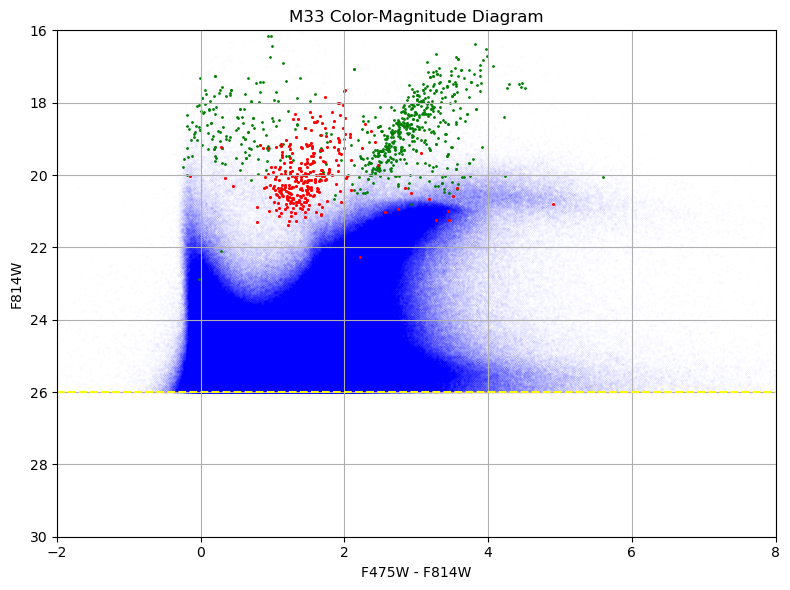

In [9]:
plt.figure(figsize = (8,6))
plt.scatter(f475w-f814w, f814w, s=0.01, alpha = 0.1, c = "blue")
plt.scatter(color, match_f814w, s=1, alpha = 1, c = "red")
plt.scatter(weak_f475w-weak_f814w, weak_f814w, s=1, alpha =1, c = "green")
plt.scatter(color, match_f814w, s=1, alpha = 1, c = "red")
plt.axhline(26, color = "yellow", linestyle = "--")
plt.xlim(-2,8)
plt.ylim(30, 16)
plt.xlabel("F475W - F814W")
plt.ylabel("F814W")
plt.title("M33 Color-Magnitude Diagram")
plt.grid(True)
plt.tight_layout()
plt.show()